<img src="http://imgur.com/1ZcRyrc.png" style="float: left; margin: 20px; height: 55px">

# Time Series EDA Lab

---

This lab covers the exploratory toolkit you need **before** fitting any time series model. It walks through: 

- Loading and indexing a real-world time series
- Visualizing trend by resampling / rolling smoothing
- Testing for stationarity with the Augmented Dickey-Fuller (ADF) test
- Diagnosing the series using ACF and PACF plots

## About the Data

`residents.csv` contains a **quarterly resident population count**, in thousands, from **April 1971 to April 1993** (89 quarters):

| Column | Description |
|---|---|
| `date` | Quarter (month-year, e.g. `04-1971`) |
| `residents` | Resident population that quarter, in thousands |

We're going to hold the **final 8 quarters (1991–1993)** out completely. Everything in this EDA lab uses only the first **81 quarters (1971–1990)**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.style.use('fivethirtyeight')

%config InlineBackend.figure_format = 'retina'
%matplotlib inline

## Part 1 - Load and Set Aside the Holdout 

### 1. Load `residents.csv`, parse `date` as a datetime (format is `MM-YYYY`), and set it as the index.

In [27]:
# YOUR CODE HERE
df = pd.read_csv('./data/residents.csv', parse_dates=['date'], date_format='%m-%Y')
df.head()

,date,residents
0,1971-04-01,13067.3
1,1971-07-01,13130.5
2,1971-10-01,13198.4
3,1972-01-01,13254.2
4,1972-04-01,13303.7


In [28]:
df['date']

0    1971-04-01
1    1971-07-01
2    1971-10-01
3    1972-01-01
4    1972-04-01
        ...    
84   1992-04-01
85   1992-07-01
86   1992-10-01
87   1993-01-01
88   1993-04-01
Name: date, Length: 89, dtype: datetime64[us]

### 2. Set aside the final 8 quarters (1991–1993) as `holdout_df`. Keep the remaining 81 quarters (1971–1990) as `df_eda`.

In [29]:
# YOUR CODE HERE
df = df.set_index('date')

In [30]:
df_eda = df.iloc[:-8].copy()
holdout_df = df.iloc[-8:].copy()

print("EDA rows:", len(df_eda))
print("Holdout rows:", len(holdout_df))

EDA rows: 81
Holdout rows: 8


### 3. Plot the raw `residents` series. What do you notice about the overall trend? Does the quarter-to-quarter spread look roughly constant, or does it change over time?

<Axes: xlabel='date'>

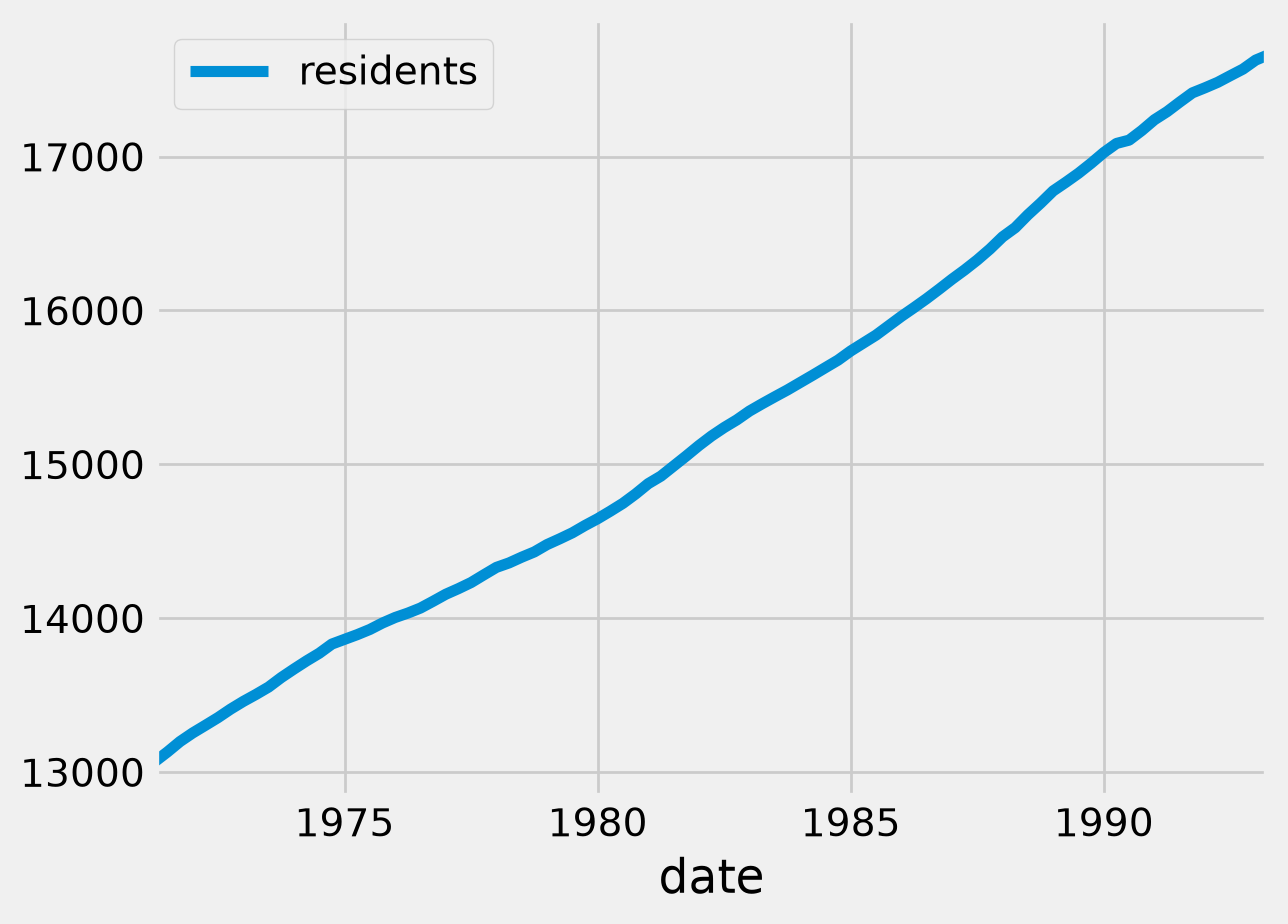

In [31]:
df.plot()

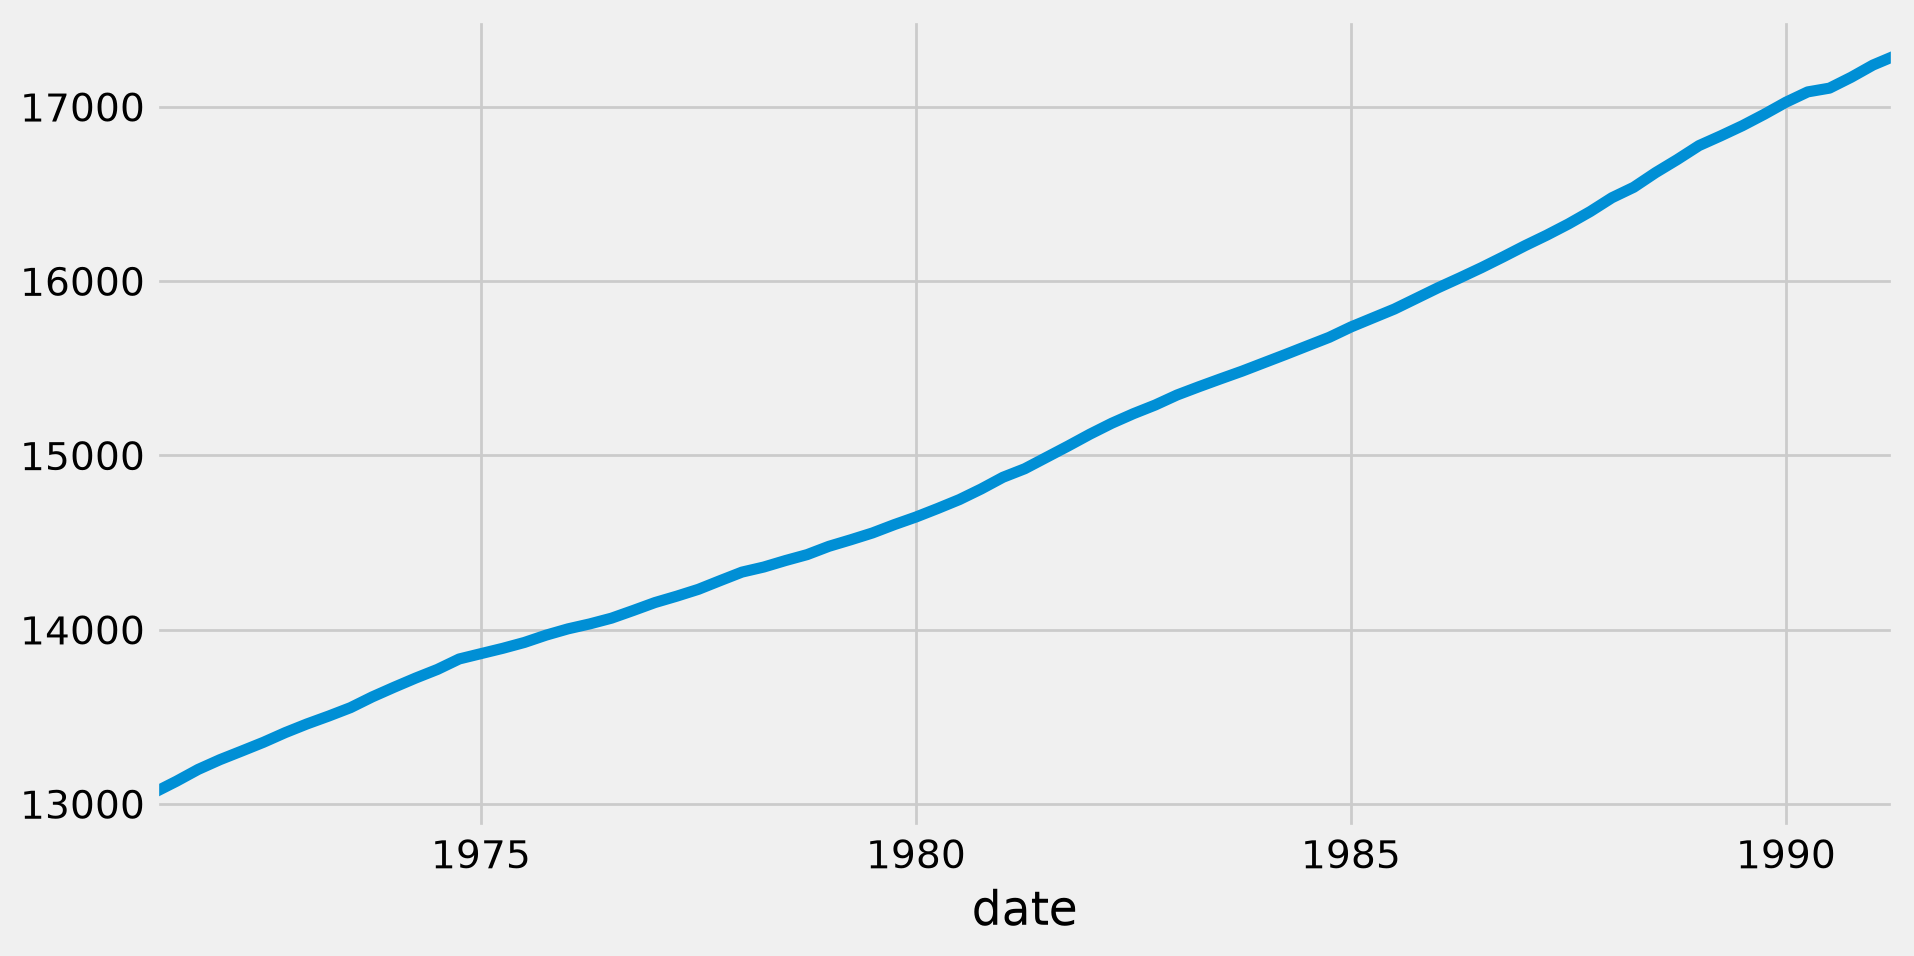

In [32]:
# YOUR CODE HERE
df_eda['residents'].plot(figsize =(10,5))
plt.show()

## Part 2 - Seasonal Decomposition

A time series can be split into three components: **trend**, **seasonal**, and **residual**.

### 4. Decompose `residents` using `seasonal_decompose` (`period=4` since this is quarterly data). Plot the trend, seasonal, and residual components.

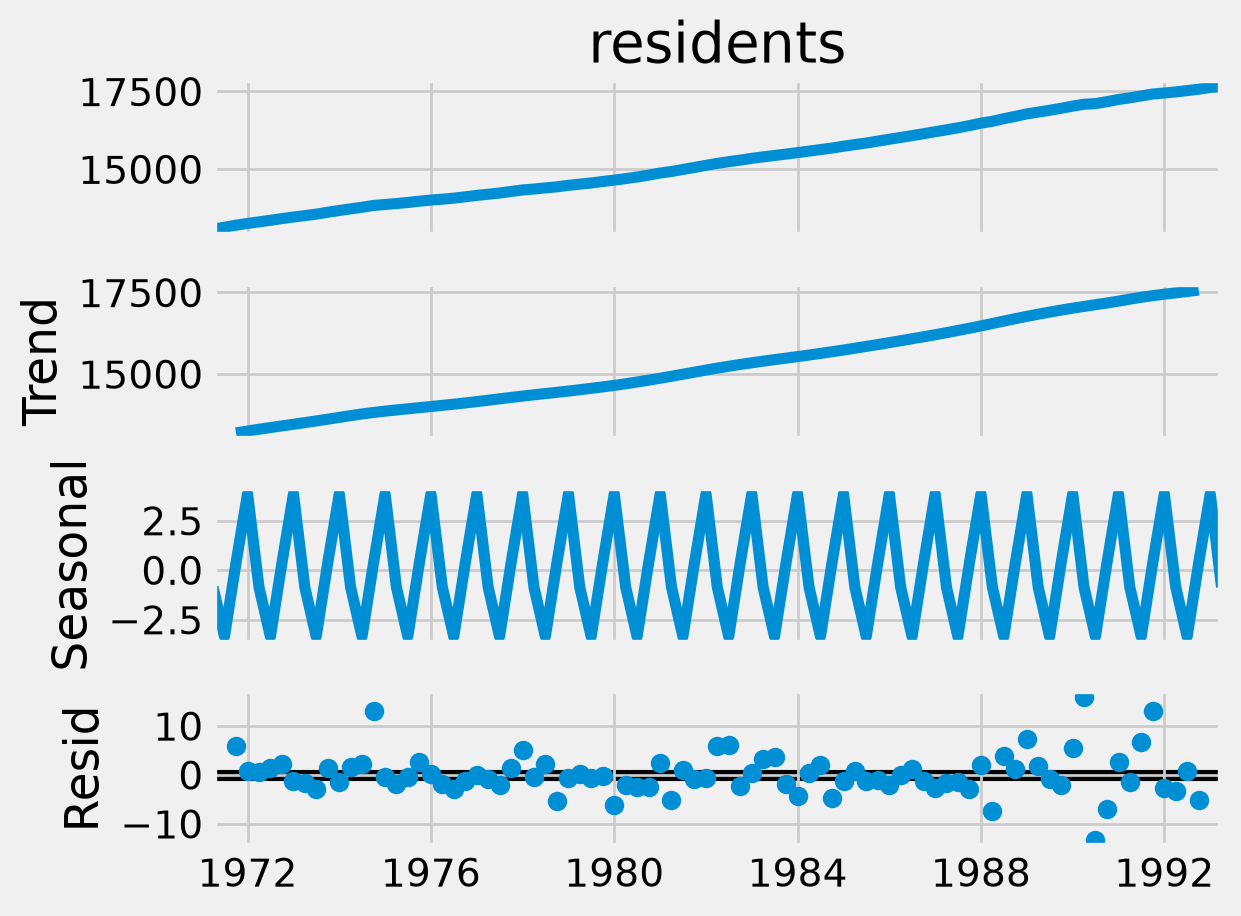

In [33]:
# YOUR CODE HERE
result = seasonal_decompose(df['residents'], period =4)
result.plot();

## Part 3 - Visualizing Trend with Rolling Mean and Resampling.

With quarterly data, a 4-quarter (1-year) rolling window is the suitable choice, as it averages away any seasonal fluctuations and leaves just the trend.

### 5. Compute and plot a 4-quarter rolling mean of `residents`, overlaid on the raw series.

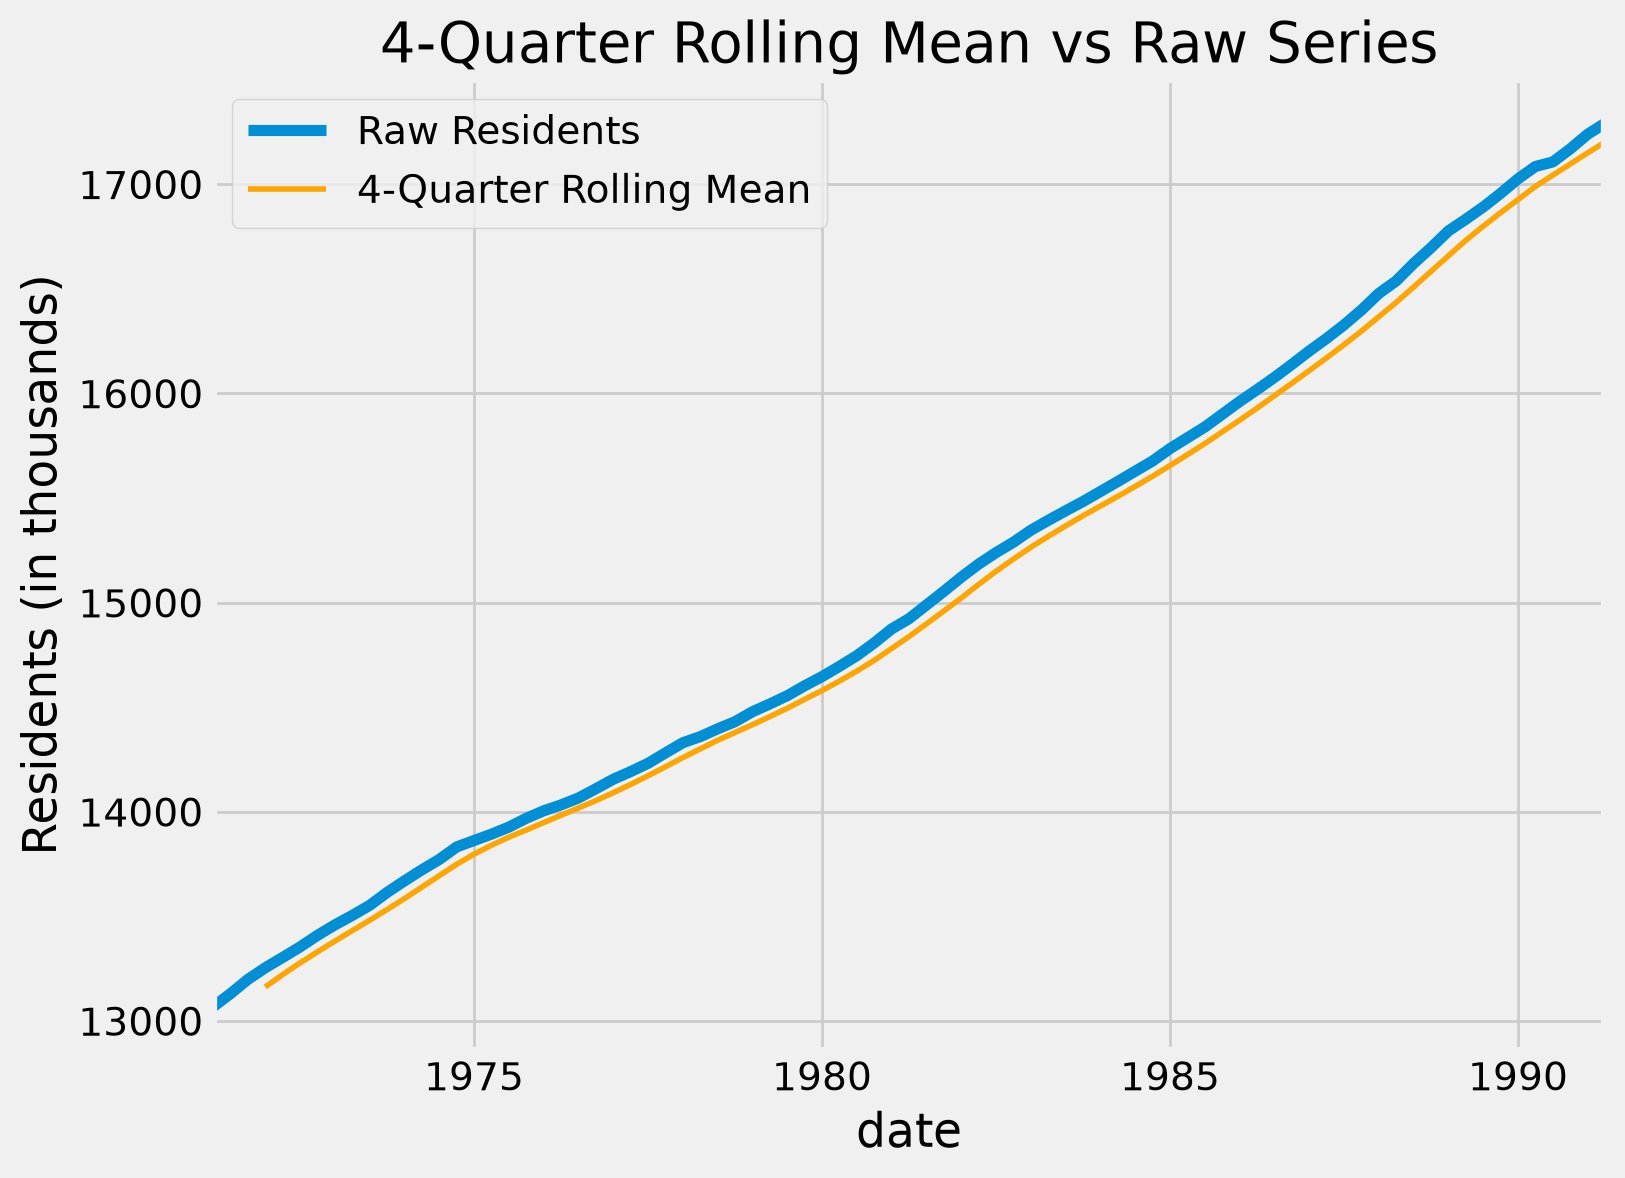

In [34]:
# YOUR CODE HERE
df_eda['rolling_mean_4q'] = df_eda['residents'].rolling(window=4).mean()
ax = df_eda['residents'].plot(figsize=(8, 6), label='Raw Residents', title='4-Quarter Rolling Mean vs Raw Series')
df_eda['rolling_mean_4q'].plot(ax=ax, label='4-Quarter Rolling Mean', color='orange', linewidth=2)

plt.ylabel('Residents (in thousands)')
plt.legend()
plt.show()

### 6. Plot a 4-quarter rolling standard deviation. Is the spread of fluctuations roughly stable over time, or does it change?

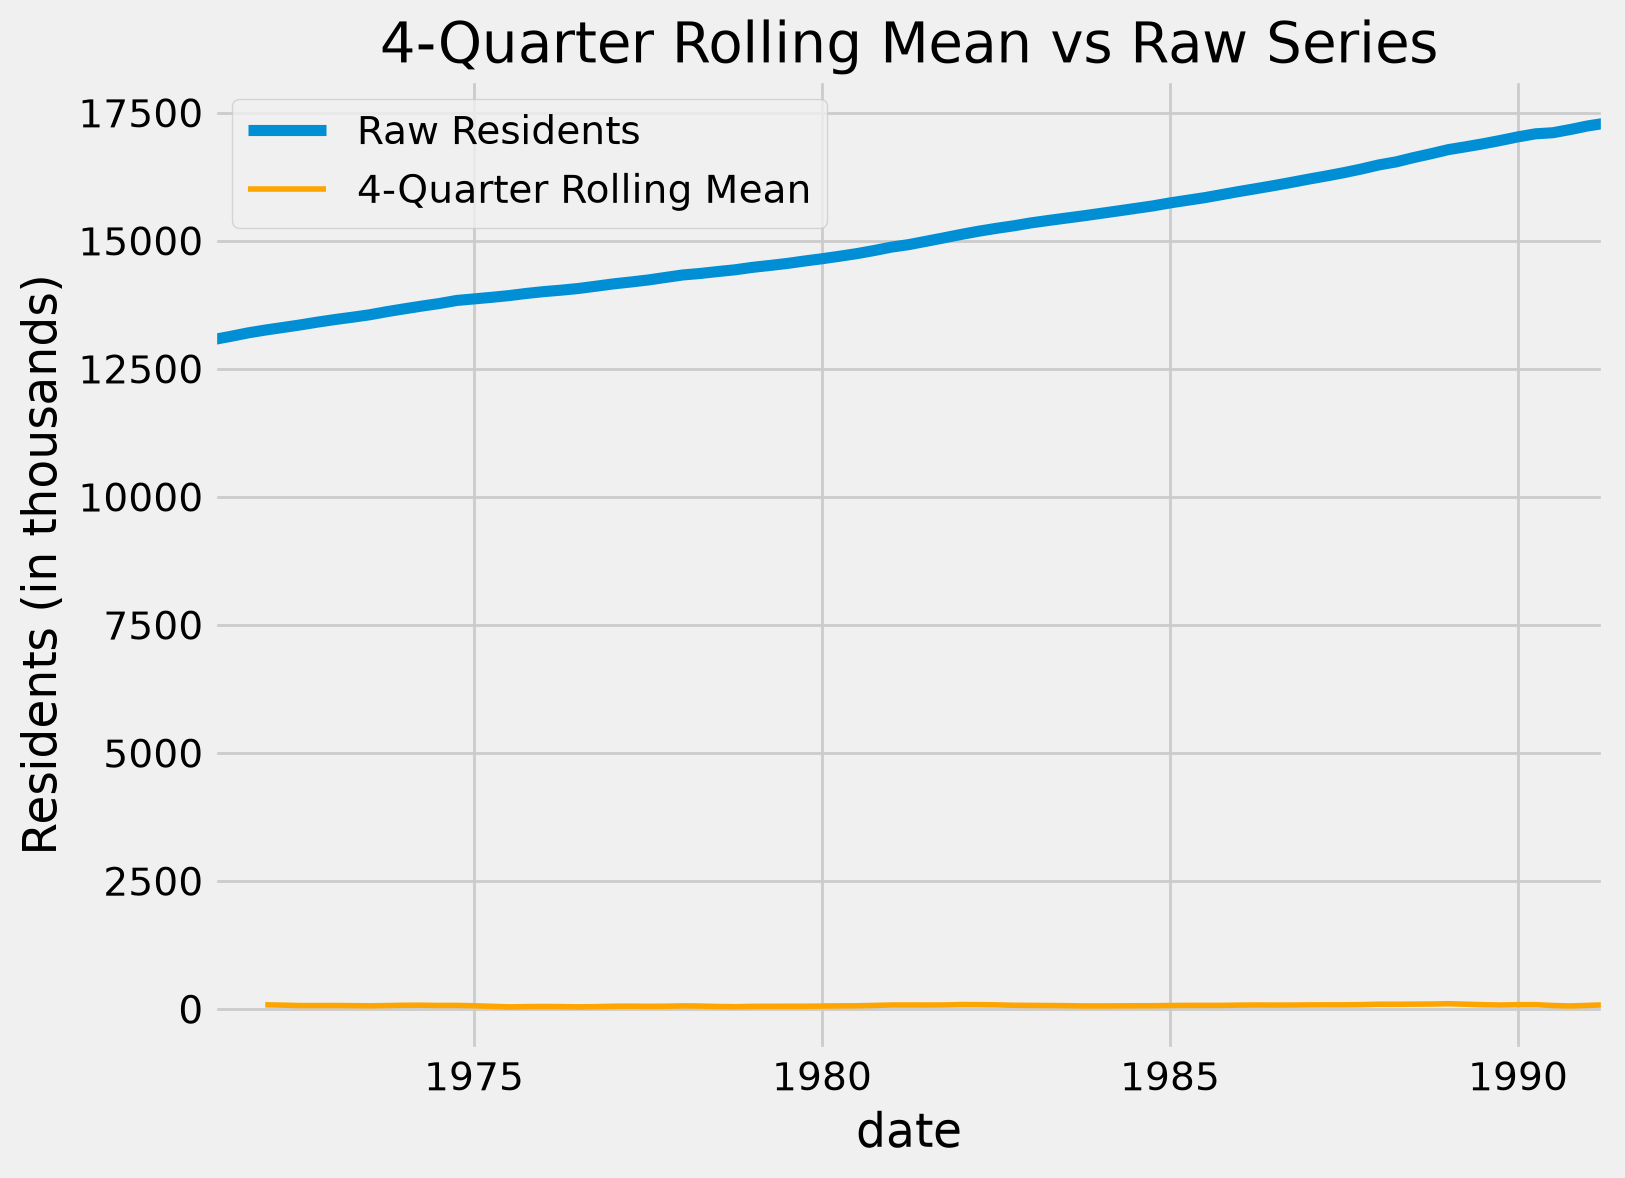

In [35]:
# YOUR CODE HERE
df_eda['rolling_mean_4q'] = df_eda['residents'].rolling(window=4).std()
ax = df_eda['residents'].plot(figsize=(8, 6), label='Raw Residents', title='4-Quarter Rolling Mean vs Raw Series')
df_eda['rolling_mean_4q'].plot(ax=ax, label='4-Quarter Rolling Mean', color='orange', linewidth=2)

plt.ylabel('Residents (in thousands)')
plt.legend()
plt.show()

## Part 4 - Stationarity and the ADF Test

A stationary series has a constant mean, variance, and autocorrelation structure over time *(most classical forecasting models assume this)*. We test for it with the **Augmented Dickey-Fuller (ADF) test**:

- **Null hypothesis (H0):** the series has a unit root (i.e. it is *non-stationary*).
- If the p-value is small (typically ≤ 0.05), we reject H0 and conclude the series **is** *stationary*.

### 7. Write an `adf_test()` helper function that runs `adfuller()` and prints the test statistic, p-value, and a plain-English conclusion.

In [37]:
def adf_test(series):
    """
    Pass in a time series, and prints an ADF report.
    """
    # YOUR CODE HERE
    result = adfuller(series.dropna(), autolag ='AIC')

    labels = ['ADF test statistic','p-value','# lags used','# observations']
    out = pd.Series(result[0:4],index=labels)

    for key,val in result[4].items():
        out[f'critical value ({key})']=val
        
    print(out.to_string())    

    if result[1] <= 0.05:
        print("Strong evidence against the null hypothesis")
        print("Reject the null hypothesis")
        print("Data has no unit root and is stationary")
    else:
        print("Weak evidence against the null hypothesis")
        print("Fail to reject the null hypothesis")
        print("Data has a unit root and is non-stationary")

### 8. Run `adf_test()` on the raw `residents` series. Then apply `.diff()` and run it again. Is one difference enough?

In [38]:
adf_test(df['residents'])

ADF test statistic       0.517268
p-value                  0.985389
# lags used              4.000000
# observations          84.000000
critical value (1%)     -3.510712
critical value (5%)     -2.896616
critical value (10%)    -2.585482
Weak evidence against the null hypothesis
Fail to reject the null hypothesis
Data has a unit root and is non-stationary


In [39]:
# YOUR CODE HERE
df['residents_dff'] =df['residents'].diff()

In [65]:
adf_test(df['residents'].diff())

ADF test statistic      -1.853505
p-value                  0.354240
# lags used              3.000000
# observations          84.000000
critical value (1%)     -3.510712
critical value (5%)     -2.896616
critical value (10%)    -2.585482
Weak evidence against the null hypothesis
Fail to reject the null hypothesis
Data has a unit root and is non-stationary


In [40]:
df.head()

,residents,residents_dff
date,,
1971-04-01,13067.3,NaN
1971-07-01,13130.5,63.2
1971-10-01,13198.4,67.9
1972-01-01,13254.2,55.8
1972-04-01,13303.7,49.5


### 9. If the first difference wasn't enough, try a second difference (`.diff().diff()`). Is it stationary now? 
*This will be your `d` term in the modeling stage*.

In [54]:
# YOUR CODE HERE
df['residents_diff2'] =df['residents'].diff().diff()

In [55]:
df.head()

,residents,residents_dff,residents_diff2
date,,,
1971-04-01,13067.3,NaN,NaN
1971-07-01,13130.5,63.2,NaN
1971-10-01,13198.4,67.9,4.7
1972-01-01,13254.2,55.8,-12.1
1972-04-01,13303.7,49.5,-6.3


In [56]:
adf_test(df['residents_diff2'])

ADF test statistic     -8.872347e+00
p-value                 1.387048e-14
# lags used             2.000000e+00
# observations          8.400000e+01
critical value (1%)    -3.510712e+00
critical value (5%)    -2.896616e+00
critical value (10%)   -2.585482e+00
Strong evidence against the null hypothesis
Reject the null hypothesis
Data has no unit root and is stationary


## Part 5 - Autocorrelation and Seasonality

ACF and PACF plots show how correlated a series is with its own past values at different lags. We look at these on the **differenced** series, with the trend removed, any repeating seasonal correlation stands out clearly instead of being buried under the trend's slow decay.

### 10. Plot the ACF and PACF of the series out to at least 20 lags.

In [62]:
# YOUR CODE HERE
def autocorr_plots(y, lags=None):
    fig, ax = plt.subplots(ncols=2, figsize=(12, 4),)
    plot_acf(y, lags=lags, ax=ax[0])
    plot_pacf(y, lags=lags, ax=ax[1])
    return fig, ax

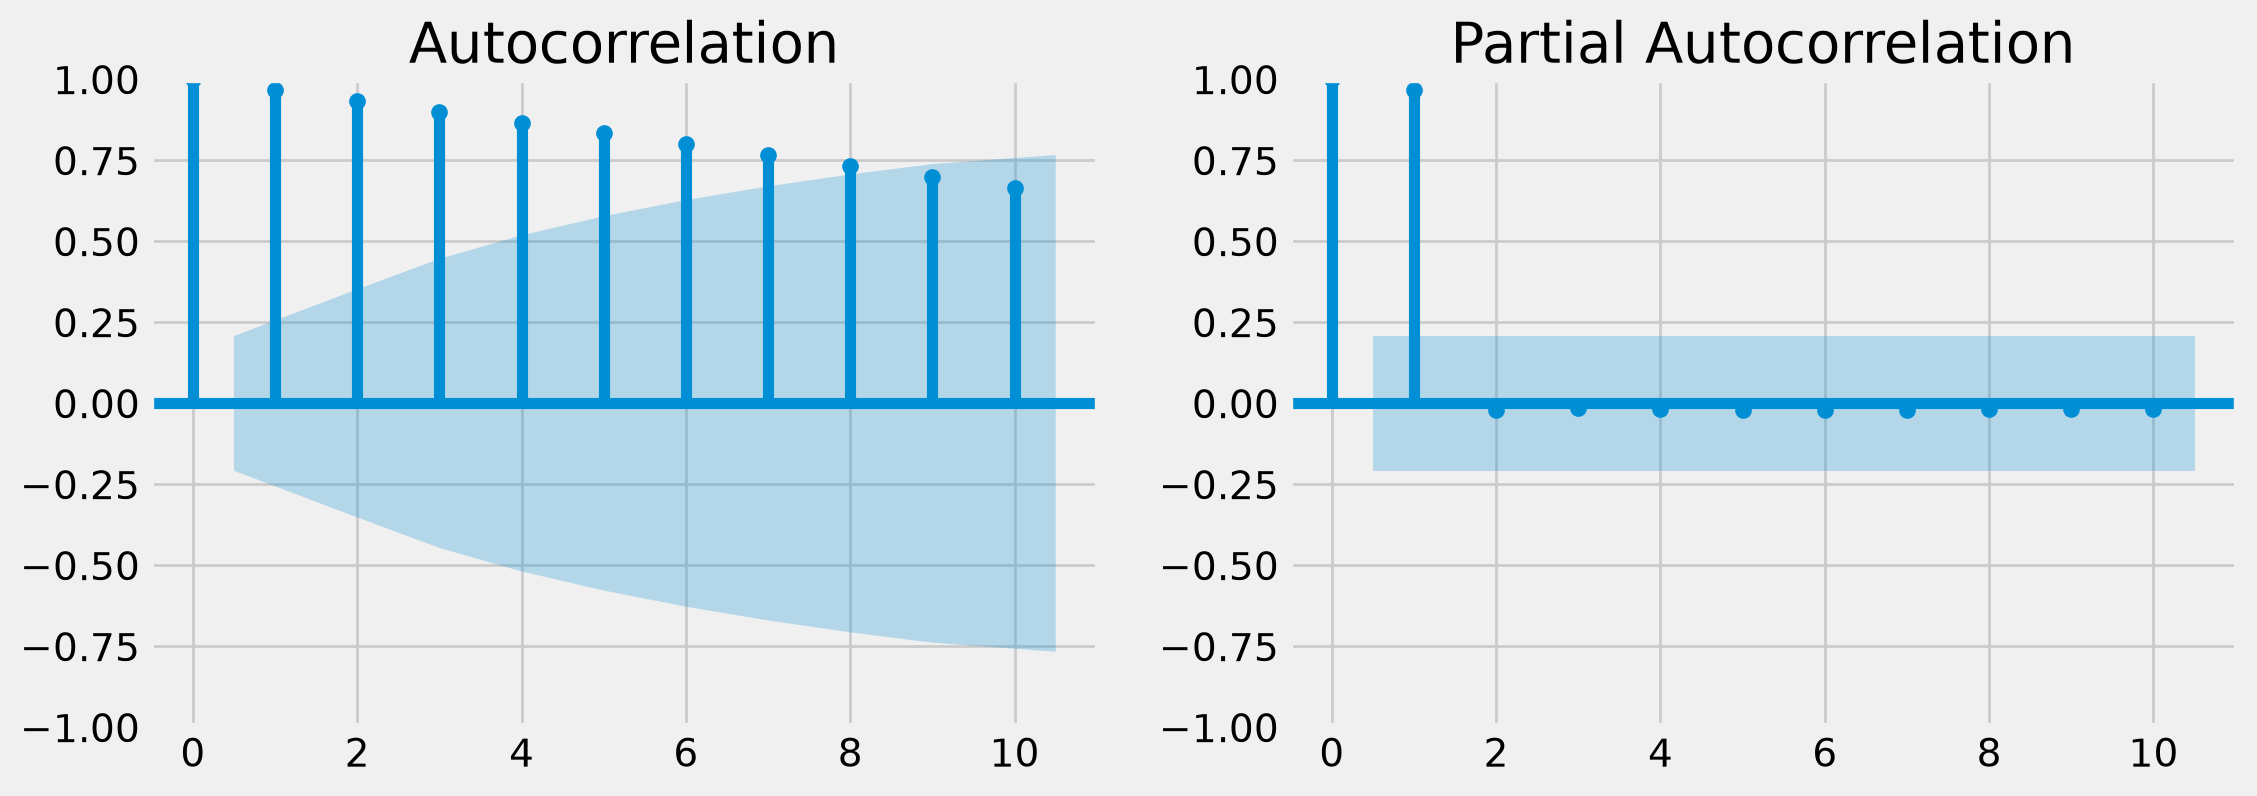

In [63]:
autocorr_plots(df['residents'], lags =10);

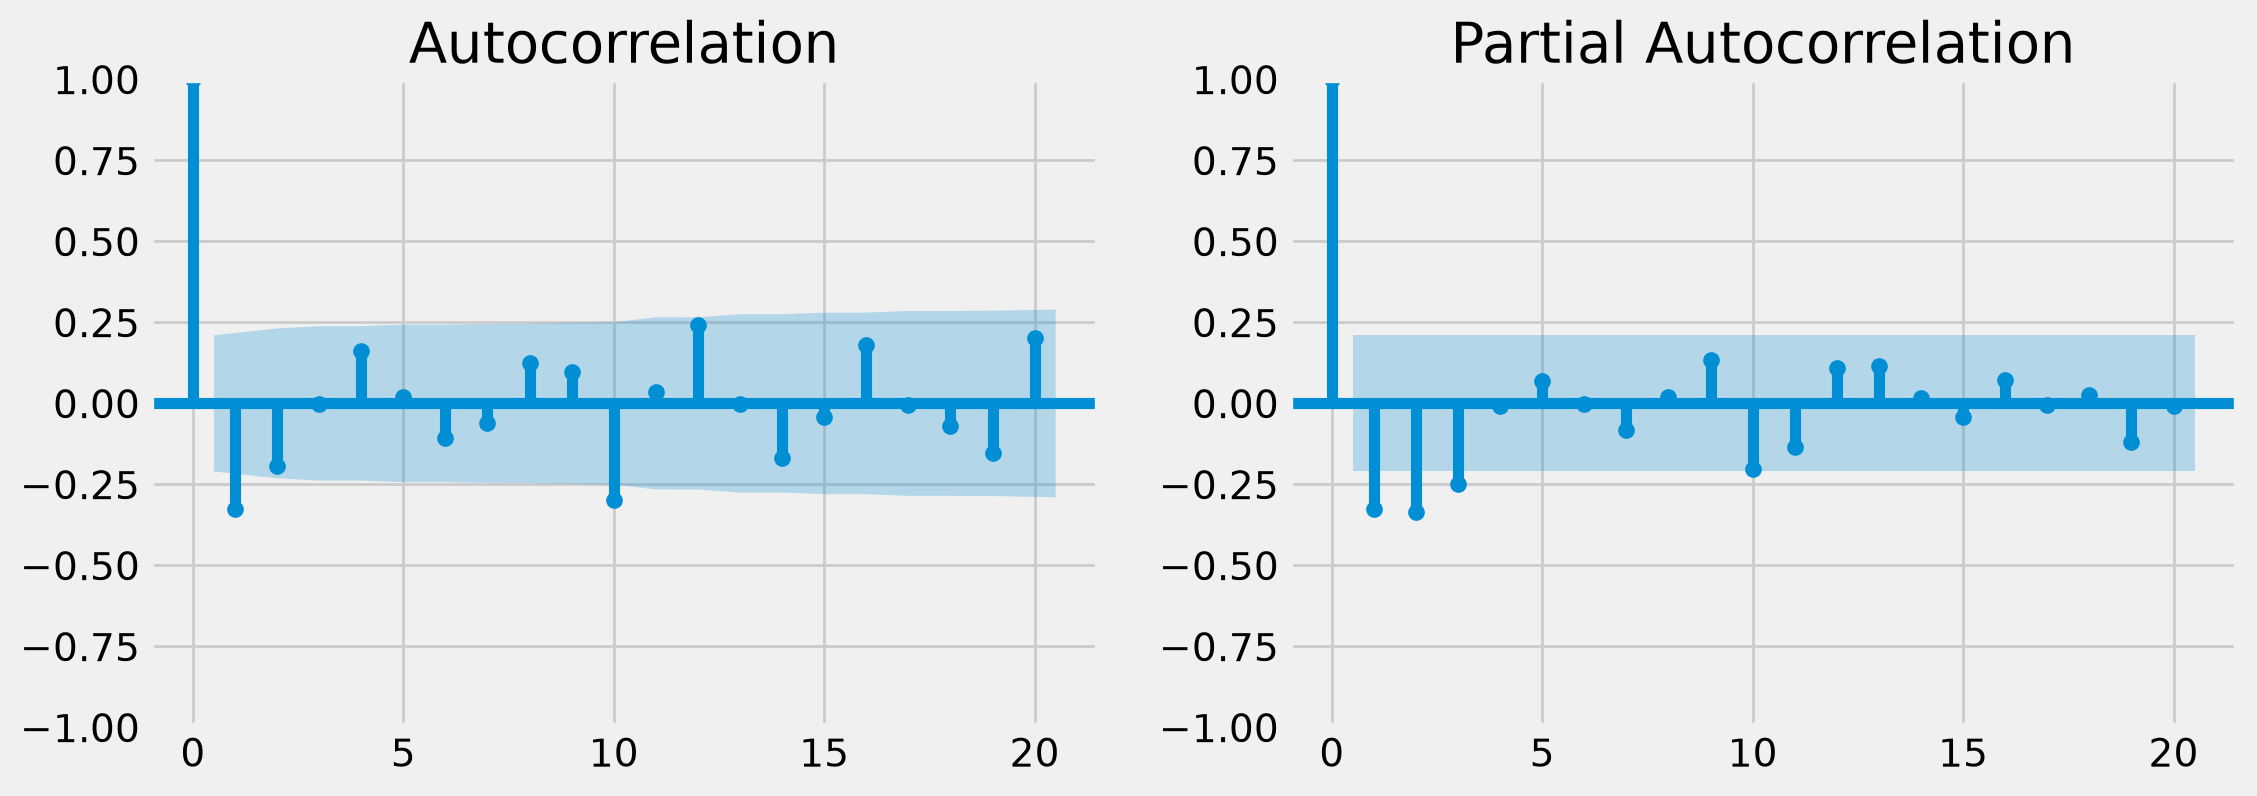

In [71]:
autocorr_plots(df['residents'].diff().diff().dropna(), lags =20);

### 11. Look closely at the ACF plot. At which lag do you see the strongest spike? What does that tell you about the data?

_Your answer here_
The first input is important after differencing (.diff()), as well as now it is stationary.